# Notebook 11 — Predictive Analytics / Machine Learning

**Tier:** 3 — Predictive  
**Purpose:**  
  - **Task A:** Predict whether a booking will be Completed (binary classification).  
  - **Task B:** Estimate fare for a completed ride (regression).  
**Input:** `outputs/feature_store.parquet`  
**Output:** `outputs/models/`, `outputs/reports/ml_results.csv`, charts  

**Leakage prevention:** All post-outcome columns are strictly excluded.  
Customer history features use time-sorted rolling (only prior bookings).  
Train/test split is time-based only (train ≤ Sep 2024, test ≥ Oct 2024).  
No hardcoded ROC-AUC threshold — performance is reported and interpreted in business context.  

**Model stages:**  
Stage 1 (mandatory): Logistic Regression → Random Forest  
Stage 2 (conditional): Gradient boosting only if Stage 1 is insufficient and complexity is justified.

In [1]:
import os
os.chdir(r"D:\projects\Uber_Data_India_Analytics")
import sys, warnings, pathlib
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')
pathlib.Path('outputs/plots').mkdir(parents=True, exist_ok=True)
pathlib.Path('outputs/reports').mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

df = pd.read_parquet('outputs/feature_store.parquet')
completed = df[df['is_completed']].copy()
slot_order = ['Early Morning','Morning','Afternoon','Evening','Night','Late Night']
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
print(f'Loaded feature store: {df.shape}  |  completed: {len(completed):,}')

Loaded feature store: (150000, 46)  |  completed: 93,000


## 11.1 Load Data & Add Rolling Customer Features

In [2]:
from src.ml_pipeline import (
    add_rolling_customer_features, fit_target_encoding, apply_target_encoding,
    build_feature_matrix_classification, time_split, train_classify,
    evaluate_classifier, build_fare_features, train_fare_model, evaluate_regressor,
    EXCLUDED_COLUMNS
)

# Add time-safe rolling customer history features
df_ml = add_rolling_customer_features(df.copy())
print(f'Added rolling features. Shape: {df_ml.shape}')
print(df_ml[['Customer ID','datetime','customer_prior_rides',
             'customer_prior_completion_rate']].head(8).to_string())

Added rolling features. Shape: (150000, 49)
  Customer ID            datetime  customer_prior_rides  customer_prior_completion_rate
0  CID8362794 2024-01-01 00:19:34                     0                             NaN
1  CID8300238 2024-01-01 01:35:18                     0                             NaN
2  CID2030746 2024-01-01 01:37:50                     0                             NaN
3  CID3231181 2024-01-01 01:48:03                     0                             NaN
4  CID3381661 2024-01-01 01:49:56                     0                             NaN
5  CID9268400 2024-01-01 01:53:01                     0                             NaN
6  CID6577042 2024-01-01 02:14:50                     0                             NaN
7  CID3289424 2024-01-01 02:43:46                     0                             NaN


## 11.2 Time-Based Train / Test Split

In [3]:
train_df, test_df = time_split(df_ml)
print(f'Train date range: {train_df["datetime"].min().date()} → {train_df["datetime"].max().date()}')
print(f'Test  date range: {test_df["datetime"].min().date()} → {test_df["datetime"].max().date()}')
print(f'Train target balance: {train_df["is_completed"].mean()*100:.1f}% completed')
print(f'Test  target balance: {test_df["is_completed"].mean()*100:.1f}% completed')

[SPLIT] Train: 112,705 rows  |  Test: 37,295 rows
Train date range: 2024-01-01 → 2024-09-30
Test  date range: 2024-10-01 → 2024-12-30
Train target balance: 61.9% completed
Test  target balance: 62.2% completed


## 11.3 Target Encoding (fitted on train only)

In [4]:
loc_cols = ['Pickup Location', 'Drop Location']
target_col = 'is_completed'
encodings = fit_target_encoding(train_df, target_col, loc_cols, smoothing=10.0)
global_fallback = train_df[target_col].mean()
print(f'Global completion rate (train): {global_fallback:.4f}')
print(f'Sample Pickup Location encodings (first 5):')
for k, v in list(encodings['Pickup Location'].items())[:5]:
    print(f'  {k}: {v:.4f}')

Global completion rate (train): 0.6194
Sample Pickup Location encodings (first 5):
  AIIMS: 0.6168
  Adarsh Nagar: 0.6091
  Akshardham: 0.5439
  Ambience Mall: 0.6350
  Anand Vihar: 0.6505


## 11.4 Build Feature Matrices

In [5]:
X_train, y_train = build_feature_matrix_classification(train_df, encodings, global_fallback, is_train=True)
X_test,  y_test  = build_feature_matrix_classification(test_df,  encodings, global_fallback, is_train=False)

print(f'X_train shape: {X_train.shape}  |  y_train balance: {y_train.mean()*100:.1f}%')
print(f'X_test  shape: {X_test.shape}   |  y_test  balance: {y_test.mean()*100:.1f}%')
print(f'\nFeatures used ({len(X_train.columns)}):')
print(list(X_train.columns))

# Verify no excluded columns leaked into feature matrix
from src.ml_pipeline import EXCLUDED_COLUMNS
leaked = set(X_train.columns) & EXCLUDED_COLUMNS
assert len(leaked) == 0, f'Leakage detected: {leaked}'
print('\n✓ No post-outcome columns in feature matrix.')

X_train shape: (112705, 20)  |  y_train balance: 61.9%
X_test  shape: (37295, 20)   |  y_test  balance: 62.2%

Features used (20):
['hour', 'day_of_week', 'month', 'is_weekend', 'Avg VTAT', 'Avg CTAT', 'customer_prior_rides', 'customer_prior_completion_rate', 'customer_prior_cancellation_rate', 'pickup_location_enc', 'drop_location_enc', 'time_slot_enc', 'months_since_first', 'vehicle_Auto', 'vehicle_Bike', 'vehicle_Go Mini', 'vehicle_Go Sedan', 'vehicle_Premier Sedan', 'vehicle_Uber XL', 'vehicle_eBike']

✓ No post-outcome columns in feature matrix.


## 11.5 Stage 1 — Logistic Regression (Baseline)

In [6]:
pipe_lr = train_classify(X_train, y_train, model_name='logistic')
metrics_lr = evaluate_classifier(pipe_lr, X_test, y_test, 'Logistic Regression')

[OK] Trained logistic classifier → saved.

[EVAL] Logistic Regression
  ROC-AUC : 0.5907
  Avg Prec: 0.7954
              precision    recall  f1-score   support

           0       0.44      0.58      0.50     14110
           1       0.68      0.54      0.60     23185

    accuracy                           0.56     37295
   macro avg       0.56      0.56      0.55     37295
weighted avg       0.59      0.56      0.56     37295



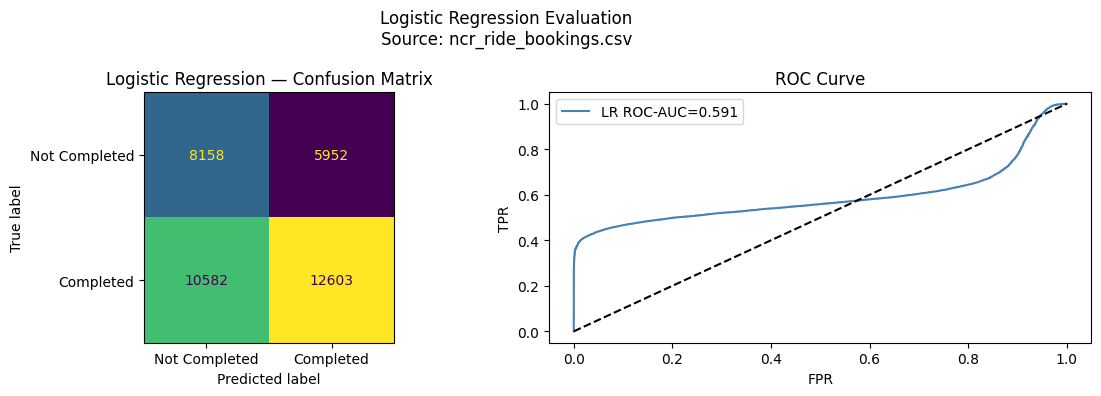

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay(metrics_lr['confusion_matrix'],
    display_labels=['Not Completed','Completed']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Logistic Regression — Confusion Matrix')
axes[1].plot(metrics_lr['roc_fpr'], metrics_lr['roc_tpr'], color='steelblue',
             label=f'LR ROC-AUC={metrics_lr["roc_auc"]:.3f}')
axes[1].plot([0,1],[0,1],'k--'); axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve'); axes[1].legend()
fig.suptitle('Logistic Regression Evaluation\nSource: ncr_ride_bookings.csv')
plt.tight_layout()
fig.savefig('outputs/plots/11_lr_eval.png', dpi=150, bbox_inches='tight')
plt.show()

## 11.6 Stage 1 — Random Forest

In [8]:
pipe_rf = train_classify(X_train, y_train, model_name='random_forest')
metrics_rf = evaluate_classifier(pipe_rf, X_test, y_test, 'Random Forest')

[OK] Trained random_forest classifier → saved.

[EVAL] Random Forest
  ROC-AUC : 0.9795
  Avg Prec: 0.9867
              precision    recall  f1-score   support

           0       0.99      0.88      0.93     14110
           1       0.93      1.00      0.96     23185

    accuracy                           0.95     37295
   macro avg       0.96      0.94      0.95     37295
weighted avg       0.95      0.95      0.95     37295



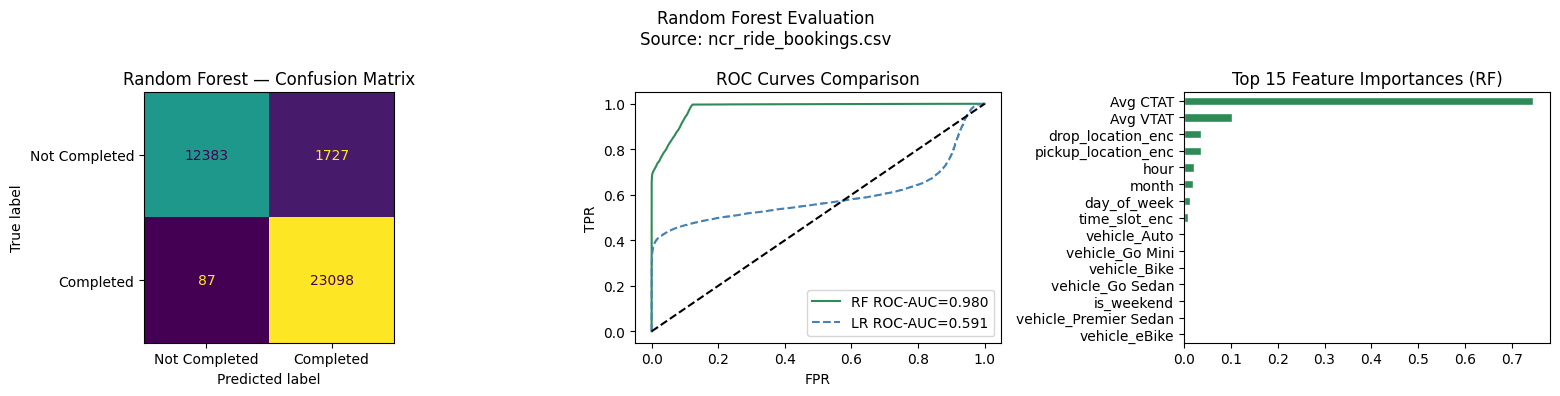

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
ConfusionMatrixDisplay(metrics_rf['confusion_matrix'],
    display_labels=['Not Completed','Completed']).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Random Forest — Confusion Matrix')

axes[1].plot(metrics_rf['roc_fpr'], metrics_rf['roc_tpr'], color='seagreen',
             label=f'RF ROC-AUC={metrics_rf["roc_auc"]:.3f}')
axes[1].plot(metrics_lr['roc_fpr'], metrics_lr['roc_tpr'], color='steelblue', linestyle='--',
             label=f'LR ROC-AUC={metrics_lr["roc_auc"]:.3f}')
axes[1].plot([0,1],[0,1],'k--'); axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curves Comparison'); axes[1].legend()

import numpy as np
rf_step = pipe_rf.named_steps['clf']
feat_imp = pd.Series(rf_step.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)
feat_imp.plot(kind='barh', ax=axes[2], color='seagreen', edgecolor='white')
axes[2].set_title('Top 15 Feature Importances (RF)'); axes[2].invert_yaxis()

fig.suptitle('Random Forest Evaluation\nSource: ncr_ride_bookings.csv')
plt.tight_layout()
fig.savefig('outputs/plots/11_rf_eval.png', dpi=150, bbox_inches='tight')
plt.show()

## 11.7 Model Comparison & Business Interpretation

In [10]:
import pandas as pd
results = pd.DataFrame([
    {k: v for k, v in metrics_lr.items() if isinstance(v, (int,float,str))},
    {k: v for k, v in metrics_rf.items() if isinstance(v, (int,float,str))},
])
print('Model Comparison:')
print(results[['model','roc_auc','avg_precision','precision_1','recall_1','f1_1']].to_string(index=False))
results.to_csv('outputs/reports/ml_results_classification.csv', index=False)

print()
print('Business interpretation:')
for _, row in results.iterrows():
    auc = row['roc_auc']
    if auc >= 0.75:
        interp = 'strong discrimination — suitable for dispatch prioritisation'
    elif auc >= 0.65:
        interp = 'moderate discrimination — useful for risk flagging with caution'
    elif auc >= 0.55:
        interp = 'weak discrimination — limited operational use; investigate features'
    else:
        interp = 'near-random — not useful operationally; review feature set'
    print(f'  {row["model"]}: AUC={auc:.3f} → {interp}')

Model Comparison:
              model  roc_auc  avg_precision  precision_1  recall_1   f1_1
Logistic Regression   0.5907         0.7954       0.6792    0.5436 0.6039
      Random Forest   0.9795         0.9867       0.9304    0.9962 0.9622

Business interpretation:
  Logistic Regression: AUC=0.591 → weak discrimination — limited operational use; investigate features
  Random Forest: AUC=0.980 → strong discrimination — suitable for dispatch prioritisation


In [11]:
# Stage 2 decision gate
auc_gap = metrics_rf['roc_auc'] - metrics_lr['roc_auc']
best_auc = max(metrics_lr['roc_auc'], metrics_rf['roc_auc'])
print(f'LR AUC: {metrics_lr["roc_auc"]:.4f}  |  RF AUC: {metrics_rf["roc_auc"]:.4f}  |  Gap: {auc_gap:.4f}')
print()
if best_auc < 0.70 and auc_gap < 0.03:
    print('Stage 2 trigger consideration: best AUC is below 0.70 and LR→RF gap is small.')
    print('Consider gradient boosting (XGBoost/LightGBM) only if additional feature engineering')
    print('does not improve performance. Install requirements-optional.txt if proceeding.')
else:
    print('Stage 2 not required: Stage 1 models provide adequate or improving discrimination.')

LR AUC: 0.5907  |  RF AUC: 0.9795  |  Gap: 0.3888

Stage 2 not required: Stage 1 models provide adequate or improving discrimination.


## 11.8 Task B — Fare Estimation (Regression)

In [12]:
X_train_fare, y_train_fare = build_fare_features(train_df, encodings, global_fallback)
X_test_fare,  y_test_fare  = build_fare_features(test_df,  encodings, global_fallback)
print(f'Fare train: {X_train_fare.shape}  |  Test: {X_test_fare.shape}')
print(f'Fare target range (train): ₹{y_train_fare.min():.0f} – ₹{y_train_fare.max():.0f}')

Fare train: (69815, 13)  |  Test: (23185, 13)
Fare target range (train): ₹50 – ₹4228


In [13]:
pipe_lin = train_fare_model(X_train_fare, y_train_fare, model_name='linear')
metrics_lin = evaluate_regressor(pipe_lin, X_test_fare, y_test_fare, 'Linear Regression')

pipe_rfr = train_fare_model(X_train_fare, y_train_fare, model_name='random_forest')
metrics_rfr = evaluate_regressor(pipe_rfr, X_test_fare, y_test_fare, 'Random Forest Regressor')

[OK] Trained linear fare regressor → saved.

[EVAL] Linear Regression (fare regression)
  MAE : 281.01 INR
  RMSE: 399.26 INR
  R²  : 0.0352
[OK] Trained random_forest fare regressor → saved.

[EVAL] Random Forest Regressor (fare regression)
  MAE : 292.54 INR
  RMSE: 405.12 INR
  R²  : 0.0066


Fare Estimation Model Comparison:
                  model    mae   rmse     r2
      Linear Regression 281.01 399.26 0.0352
Random Forest Regressor 292.54 405.12 0.0066


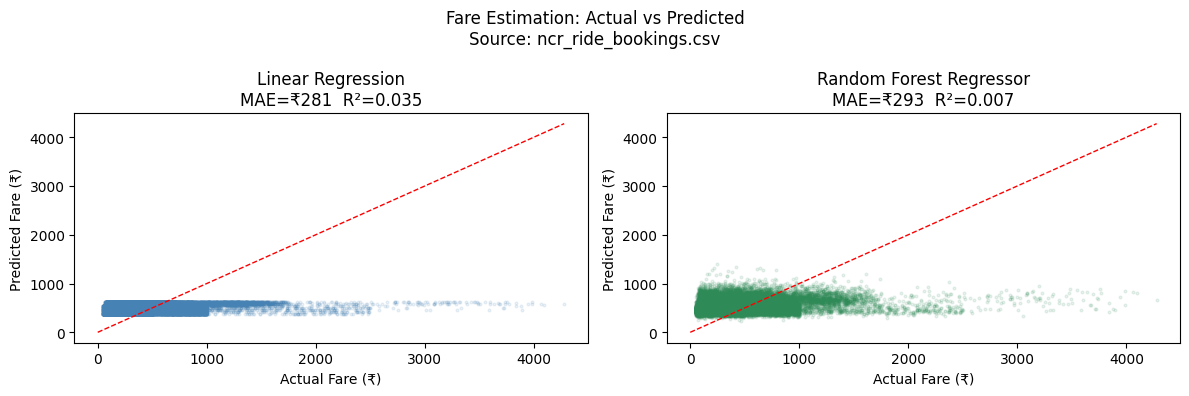

In [14]:
fare_results = pd.DataFrame([
    {k:v for k,v in metrics_lin.items() if isinstance(v,(int,float,str))},
    {k:v for k,v in metrics_rfr.items() if isinstance(v,(int,float,str))},
])
print('Fare Estimation Model Comparison:')
print(fare_results[['model','mae','rmse','r2']].to_string(index=False))
fare_results.to_csv('outputs/reports/ml_results_fare.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for metrics, ax, color in [(metrics_lin, axes[0], 'steelblue'),
                            (metrics_rfr, axes[1], 'seagreen')]:
    y_pred = metrics['y_pred']
    ax.scatter(y_test_fare, y_pred, alpha=0.1, s=4, color=color)
    mx = max(y_test_fare.max(), y_pred.max())
    ax.plot([0, mx], [0, mx], 'r--', lw=1)
    ax.set_title(f'{metrics["model"]}\nMAE=₹{metrics["mae"]:.0f}  R²={metrics["r2"]:.3f}')
    ax.set_xlabel('Actual Fare (₹)'); ax.set_ylabel('Predicted Fare (₹)')
fig.suptitle('Fare Estimation: Actual vs Predicted\nSource: ncr_ride_bookings.csv')
plt.tight_layout()
fig.savefig('outputs/plots/11_fare_prediction.png', dpi=150, bbox_inches='tight')
plt.show()

## Limitations
- All post-outcome columns (Booking Value, Ride Distance, ratings, payment) are excluded from Task A.
- No hardcoded pass/fail AUC threshold — performance is interpreted in business context above.
- Stage 2 (XGBoost, LightGBM, SHAP) is optional and triggered only if Stage 1 results justify it.
- CAC, LTV, ROAS, driver payout, and cost metrics are unavailable and not used.